In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df= pd.read_csv(r"C:\Users\ameya\Dropbox\PC\Downloads\internship oasis infobyte\retail_sales_dataset.csv")

In [16]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# performed initial inspection

In [17]:
df.shape

(1000, 9)

In [18]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [19]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

# Descriptive statistics

In [20]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


#### mean = 500.500000, median = 500.500000, standard deviation = 288.819436

#  Time series analysis: plot monthly and quarterly sales trends using line charts

In [21]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

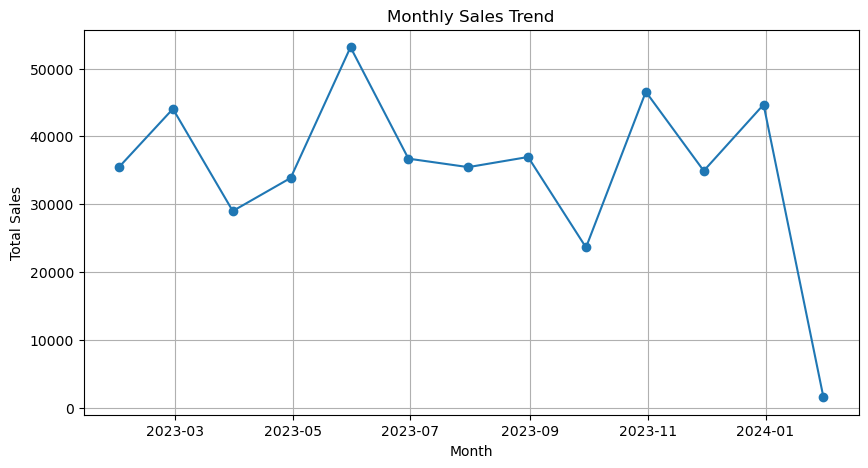

In [23]:
monthly_sales = df.resample('ME', on='Date')['Total Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

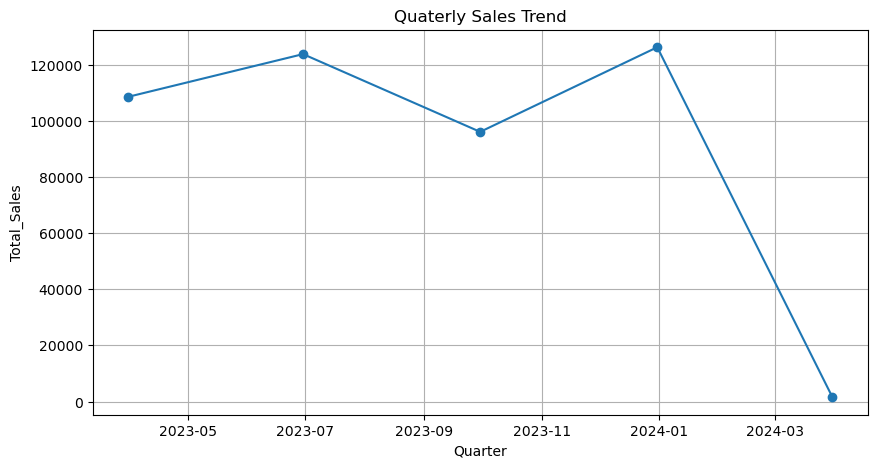

In [24]:
quater_sales = df.resample('QE',on='Date')['Total Amount'].sum()
plt.figure(figsize=(10,5))
plt.plot(quater_sales.index, quater_sales.values, marker="o")
plt.title("Quaterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total_Sales")
plt.grid(True)
plt.show()

In [25]:
quater_sales.index

DatetimeIndex(['2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31',
               '2024-03-31'],
              dtype='datetime64[ns]', name='Date', freq='QE-DEC')

In [26]:
quater_sales.values

array([108500, 123735,  96045, 126190,   1530])

# Customer demographics analysis

In [27]:
df['Age Group'] = pd.cut(df['Age'], bins=[0,20,30,40,50,60,100], labels=['Below 20','21-31','31-40','41-50','51-60','60 Above'])

In [28]:
age_group= df['Age Group'].value_counts().sort_index()

Text(0, 0.5, 'Number of Customers')

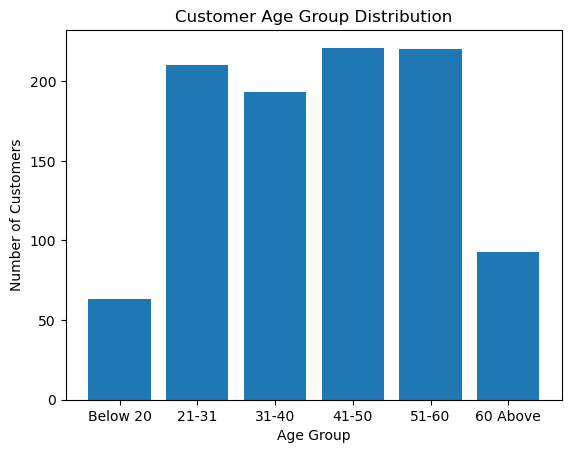

In [29]:
plt.bar(age_group.index,age_group.values)
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

In [30]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,31-40
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,21-31
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,41-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,31-40
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,21-31


In [31]:
top_10 = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(10)

Text(0, 0.5, 'Quantity')

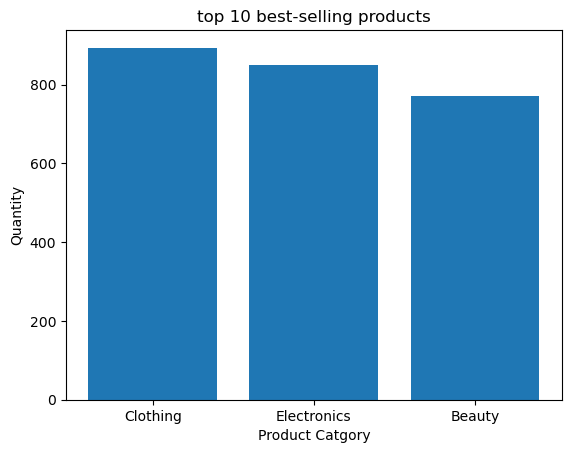

In [34]:
plt.bar(top_10.index,top_10.values)
plt.title("top 10 best-selling products")
plt.xlabel("Product Catgory")
plt.ylabel("Quantity")

# Heatmap

In [35]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,31-40
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,21-31
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,41-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,31-40
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,21-31


In [36]:
columns = ['Age','Quantity','Price per Unit', 'Total Amount']

In [37]:
corr = df[columns].corr()
corr

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


<Axes: >

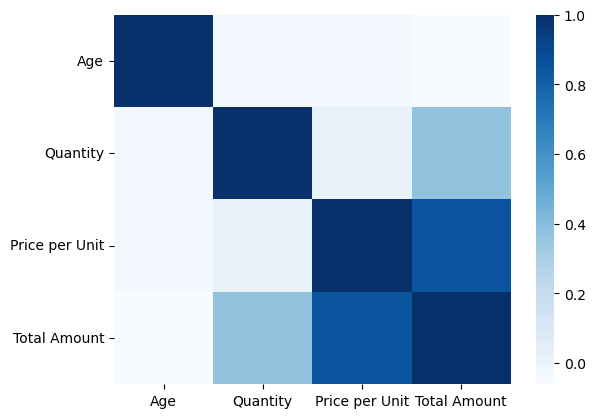

In [41]:
sns.heatmap(corr,cmap='Blues')

# At least one additional visualisation of your choice that reveals a non-obvious insight

In [42]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,31-40
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,21-31
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,41-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,31-40
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,21-31


Text(0, 0.5, 'Gender')

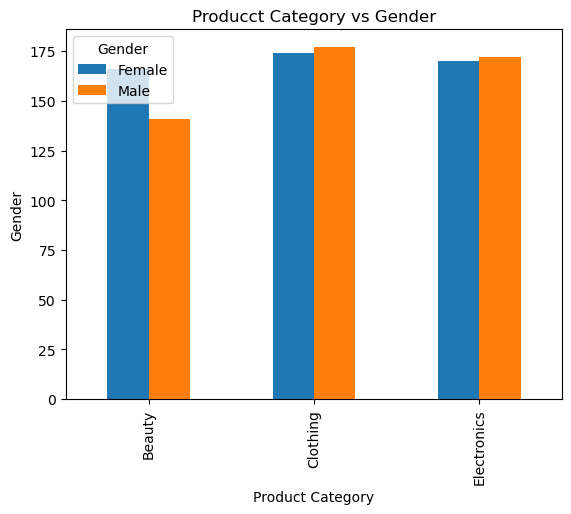

In [54]:
pd.crosstab(df['Product Category'], df['Gender']).plot(kind='bar')
plt.title('Producct Category vs Gender')
plt.xlabel('Product Category')
plt.ylabel('Gender')


# Conclusion :
## It focuses on high-value products to increase total sales .
## Quantity offers to encourage the customer to buy more.
## overall, the business can increase sales by promoting high value products and focusing on weaker sales periods.